# ME EN 7750 Scientific Machine Learning Final Project
# Reynaldo Villarreal Zambrano

## Description: The purpose of this final project is to use both Sparse Identification of Nonlinear Dynamics (SINDy) and Symbolic Regression (PySR) in order to identify governing equations that relate motor actuation inputs to the resulting acceleration dynamics, and then compare each other and their results.

In [1]:
# import libraries
import numpy as np
import pysindy
import pysr

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Example 1: Using PySR

c:\Users\reyna\source\repos\Scientific-Machine-Learning-7750\.venv\Lib\site-packages\pysr\sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
c:\Users\reyna\source\repos\Scientific-Machine-Learning-7750\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.122e-01  0.000e+00  y = 1.0422
3           8.078e-02  4.828e-01  y = x₁ + x₀
5           7.922e-02  9.768e-03  y = (x₀ + x₁) + 0.039534
6           4.779e-02  5.053e-01  y = (x₂ / cos(x₁)) + x₀
7           2.089e-02  8.278e-01  y = (x₁ + (x₀ + x₂)) - 0.45479
8           1.905e-02  9.225e-02  y = ((x₂ + x₀) * 0.84555) / cos(x₁)
10          1.302e-02  1.903e-01  y = ((exp(x₁) * 0.55417) + x₀) + (x₂ - 0.9088)
14          1.165e-02  2.765e-02  y = cos(x₂ - (cos(x₀) * 2.2693)) - (-1.4018 - sin(x₁ + -1....
                                      048))
15          1.102e-02  5.607e-02  y = cos((cos(x₀) * 2.2944) - x₂) - (-1.2579 - sin(sin(x₁ +...
                                       -0.88164)))
18          2.724e-03  4.658e-01  y = (cos((cos(x₀) * 2.3457) - x₂) - sin(0.093393 - ((x₁ + ...
                                      x₁) + -1.945

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


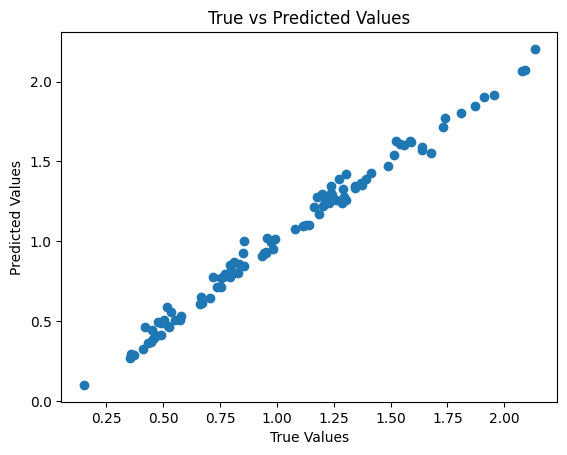

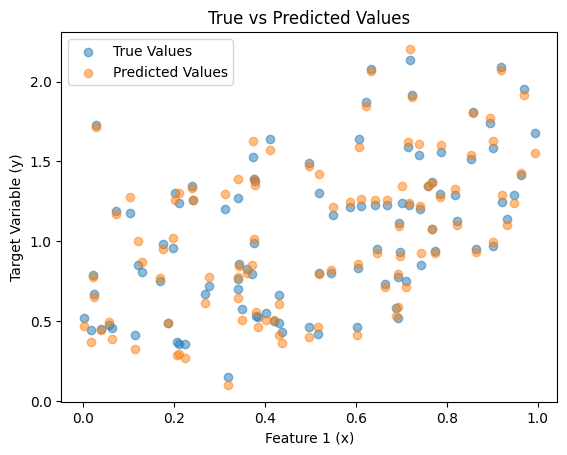

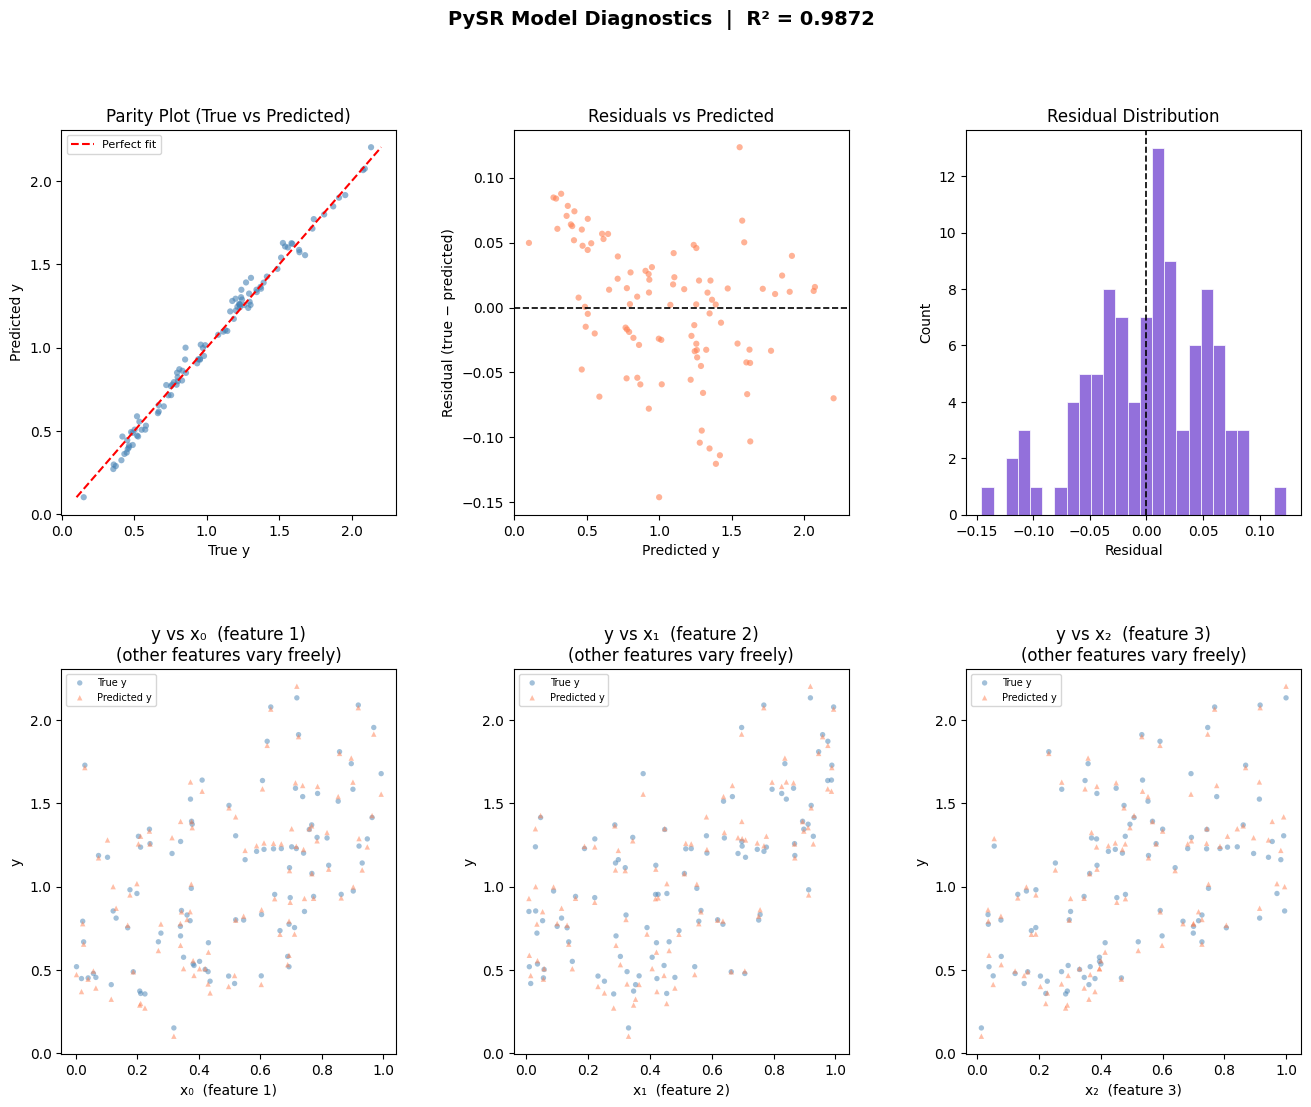

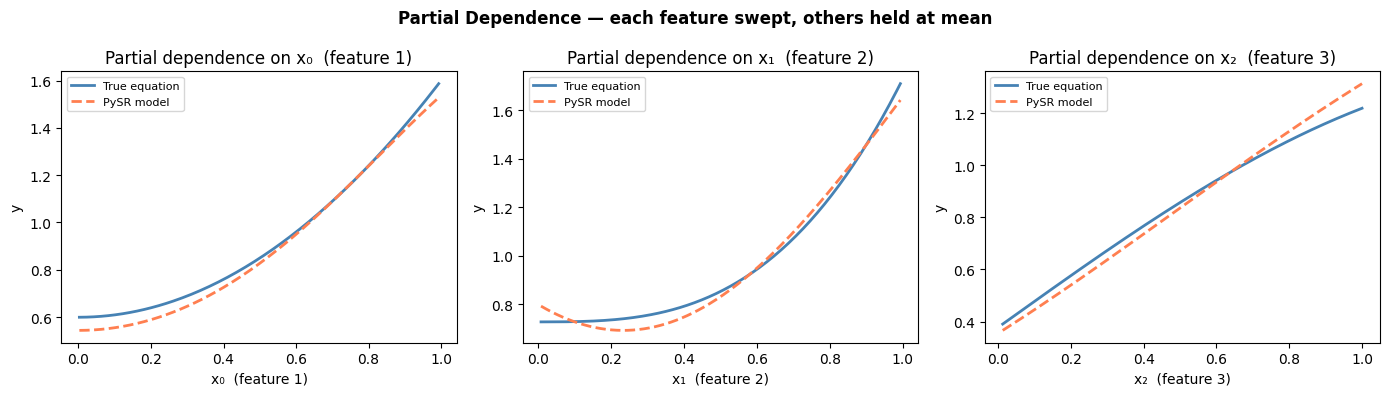

In [4]:
# Create a fake dataset
X = np.random.rand(100, 3)  # 100 samples, 3 features
y = X[:, 0]**2 + X[:, 1]**3 + np.sin(X[:, 2])  # Target variable with some non-linear relationships

# create and fit the symbolic regression model
model = pysr.PySRRegressor(
    niterations=25, # number of iterations for the genetic programming algorithm
    binary_operators=["+", "-", "*", "/"], # allowed binary operators
    unary_operators=["sin", "cos", "exp", "log"], # allowed unary operators
    model_selection="best", # select the best model based on validation performance
    loss="loss(x, y) = (x - y)^2", # custom loss function (mean squared error)
    maxsize=20, # maximum size of the expression tree
)

model.fit(X, y)  # Fit the model to the data
print(model.get_best())  # Print the best discovered equation

# plot the real vs predicted values
import matplotlib.pyplot as plt
y_pred = model.predict(X)
plt.scatter(y, y_pred)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.show()

# plot x and y for both true and predicted values
plt.scatter(X[:, 0], y, label="True Values", alpha=0.5)
plt.scatter(X[:, 0], y_pred, label="Predicted Values", alpha=0.5)
plt.xlabel("Feature 1 (x)")
plt.ylabel("Target Variable (y)")
plt.title("True vs Predicted Values")
plt.legend()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

y_pred = model.predict(X)
residuals = y - y_pred
r2 = 1 - np.sum(residuals**2) / np.sum((y - np.mean(y))**2)

fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"PySR Model Diagnostics  |  R² = {r2:.4f}", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

feature_names = ['x₀  (feature 1)', 'x₁  (feature 2)', 'x₂  (feature 3)']

# ---- Row 1: True vs Predicted (parity plot) ----
ax_parity = fig.add_subplot(gs[0, 0])
ax_parity.scatter(y, y_pred, alpha=0.6, s=20, color='steelblue', edgecolors='none')
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax_parity.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax_parity.set_xlabel("True y")
ax_parity.set_ylabel("Predicted y")
ax_parity.set_title("Parity Plot (True vs Predicted)")
ax_parity.legend(fontsize=8)

# ---- Row 1: Residuals vs Predicted ----
ax_resid = fig.add_subplot(gs[0, 1])
ax_resid.scatter(y_pred, residuals, alpha=0.6, s=20, color='coral', edgecolors='none')
ax_resid.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax_resid.set_xlabel("Predicted y")
ax_resid.set_ylabel("Residual (true − predicted)")
ax_resid.set_title("Residuals vs Predicted")

# ---- Row 1: Residual distribution ----
ax_hist = fig.add_subplot(gs[0, 2])
ax_hist.hist(residuals, bins=25, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax_hist.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax_hist.set_xlabel("Residual")
ax_hist.set_ylabel("Count")
ax_hist.set_title("Residual Distribution")

# ---- Row 2: True vs Predicted sliced along each feature ----
# Sort by each feature independently so the line plots make sense
for col in range(3):
    ax = fig.add_subplot(gs[1, col])
    sort_idx = np.argsort(X[:, col])
    x_sorted     = X[sort_idx, col]
    y_sorted      = y[sort_idx]
    y_pred_sorted = y_pred[sort_idx]

    ax.scatter(x_sorted, y_sorted,      alpha=0.5, s=15,
               color='steelblue', label='True y',      edgecolors='none')
    ax.scatter(x_sorted, y_pred_sorted, alpha=0.5, s=15,
               color='coral',     label='Predicted y', edgecolors='none', marker='^')
    ax.set_xlabel(feature_names[col])
    ax.set_ylabel("y")
    ax.set_title(f"y vs {feature_names[col]}\n(other features vary freely)")
    ax.legend(fontsize=7)

plt.show()

# ---- Separately: Partial dependence plots ----
# Fix all other features at their mean, sweep one feature at a time
fig2, axes = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle("Partial Dependence — each feature swept, others held at mean",
              fontsize=12, fontweight='bold')

x_means = X.mean(axis=0)
n_sweep = 200

for col in range(3):
    sweep_vals = np.linspace(X[:, col].min(), X[:, col].max(), n_sweep)

    # Build synthetic input: all features at mean, sweep one
    X_sweep = np.tile(x_means, (n_sweep, 1))
    X_sweep[:, col] = sweep_vals

    y_sweep_true = X_sweep[:, 0]**2 + X_sweep[:, 1]**3 + np.sin(X_sweep[:, 2])
    y_sweep_pred = model.predict(X_sweep)

    axes[col].plot(sweep_vals, y_sweep_true, 'steelblue',
                   linewidth=2, label='True equation')
    axes[col].plot(sweep_vals, y_sweep_pred, 'coral',
                   linewidth=2, linestyle='--', label='PySR model')
    axes[col].set_xlabel(feature_names[col])
    axes[col].set_ylabel("y")
    axes[col].set_title(f"Partial dependence on {feature_names[col]}")
    axes[col].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Example 2: Using SINDy

(x0)' =  1.000 x1
(x1)' = -1.000 x0
(x2)' =  0.667 1 +  0.333 x0^2 +  0.333 x1^2

R² score: 0.362788


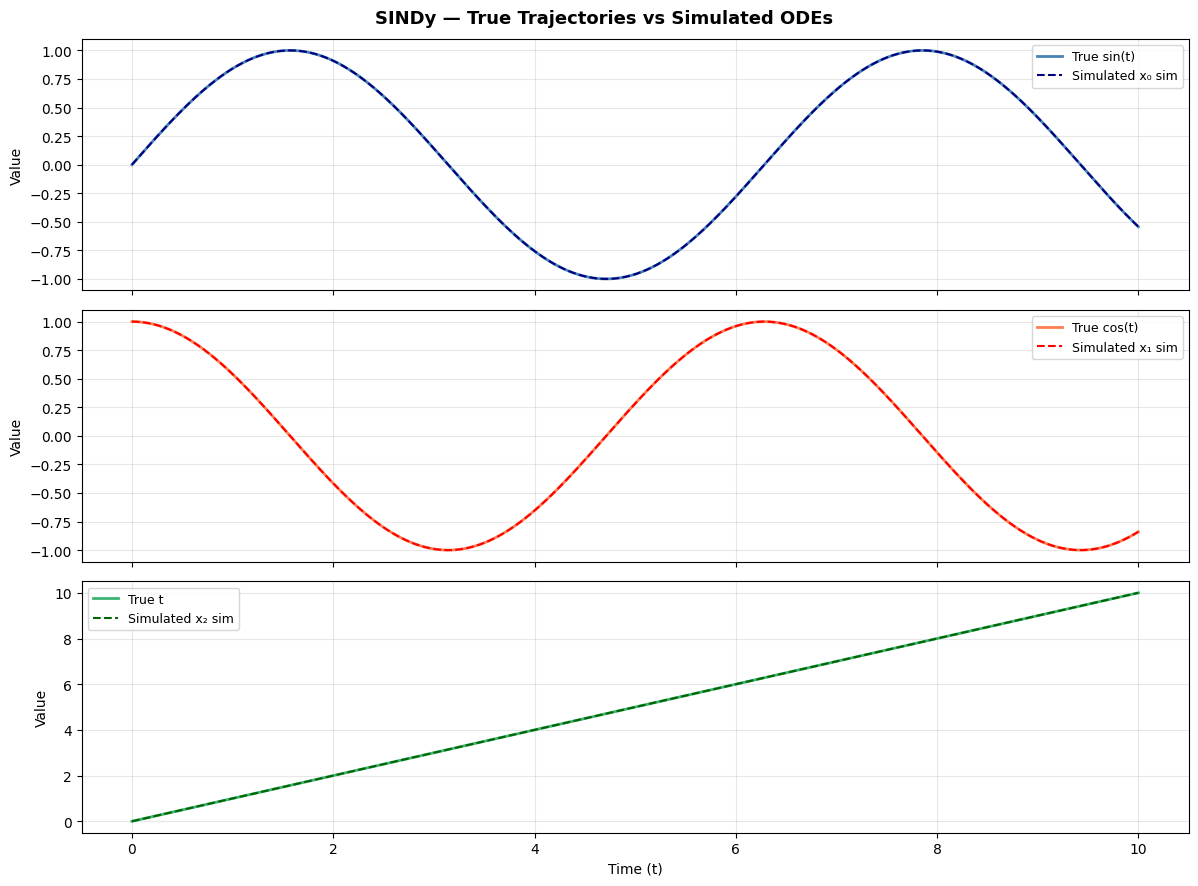

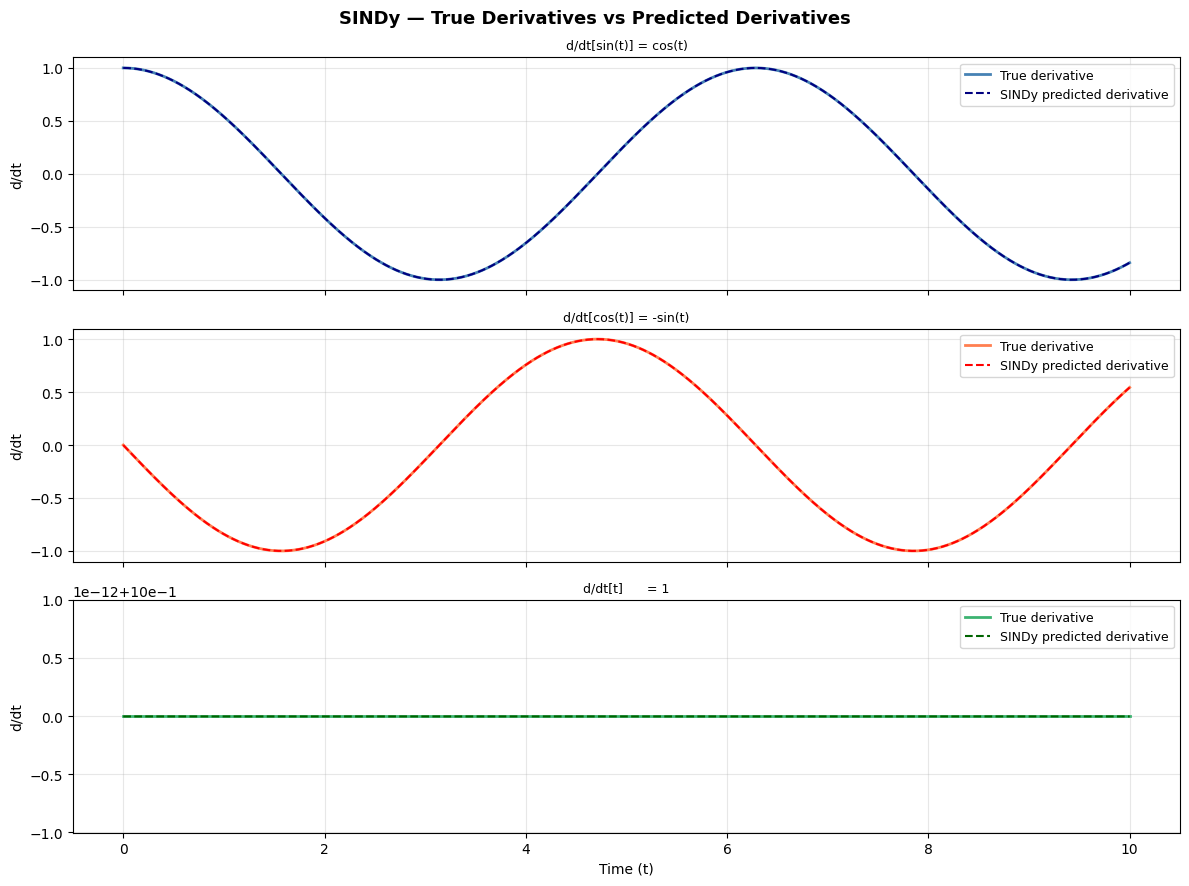

In [20]:
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt

# ---- Data ----
t  = np.linspace(0, 10, 1000)
X  = np.column_stack([np.sin(t), np.cos(t), t])

# ---- Fit SINDy ----
model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=2),  # degree 2 is enough here
    optimizer=ps.STLSQ(threshold=0.05),
    differentiation_method=ps.FiniteDifference(order=2)
)
model.fit(X, t=t)
model.print()
print(f"\nR² score: {model.score(X, t=t):.6f}")

# ---- Simulate forward from initial conditions ----
X0      = X[0, :]                     # initial state: [sin(0), cos(0), 0] = [0, 1, 0]
X_sim   = model.simulate(X0, t)       # integrate the discovered ODEs forward in time

# ---- Plot: true trajectories vs simulated trajectories ----
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("SINDy — True Trajectories vs Simulated ODEs", fontsize=13, fontweight='bold')

labels_true  = ['sin(t)',  'cos(t)',  't']
labels_pred  = ['x₀ sim', 'x₁ sim', 'x₂ sim']
colors_true  = ['steelblue', 'coral',  'mediumseagreen']
colors_pred  = ['navy',      'red',    'darkgreen']

for i in range(3):
    axes[i].plot(t, X[:, i],     color=colors_true[i], linewidth=2,
                 label=f'True {labels_true[i]}')
    axes[i].plot(t, X_sim[:, i], color=colors_pred[i], linewidth=1.5,
                 linestyle='--', label=f'Simulated {labels_pred[i]}')
    axes[i].set_ylabel("Value")
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[2].set_xlabel("Time (t)")
plt.tight_layout()
plt.show()

# ---- Plot: derivatives — what model.predict() actually returns ----
X_dot_true  = np.column_stack([ np.cos(t), -np.sin(t), np.ones_like(t)])
X_dot_pred  = model.predict(X)

fig2, axes2 = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig2.suptitle("SINDy — True Derivatives vs Predicted Derivatives", fontsize=13, fontweight='bold')

deriv_labels = ["d/dt[sin(t)] = cos(t)",
                "d/dt[cos(t)] = -sin(t)",
                "d/dt[t]      = 1"]

for i in range(3):
    axes2[i].plot(t, X_dot_true[:, i],  color=colors_true[i], linewidth=2,
                  label=f'True derivative')
    axes2[i].plot(t, X_dot_pred[:, i],  color=colors_pred[i], linewidth=1.5,
                  linestyle='--', label=f'SINDy predicted derivative')
    axes2[i].set_ylabel("d/dt")
    axes2[i].set_title(deriv_labels[i], fontsize=9)
    axes2[i].legend(fontsize=9)
    axes2[i].grid(True, alpha=0.3)

axes2[2].set_xlabel("Time (t)")
plt.tight_layout()
plt.show()